# 新能源汽车智能驾驶购买意愿分析（中文结果报告）

[中文 Notebook](01_ev_purchase_intention_zh.ipynb) · [English Notebook](01_ev_purchase_intention_en.ipynb) · [项目 README](../README.md)

本 Notebook 是**结果读取与审计报告**，不是另一套分析脚本。它调用统一的题号映射，读取一次已经完成的运行目录，不在展示层重新拟合模型、重新 bootstrap 或重新调参。

## 研究问题

项目以 Q21 的有序购买溢价意愿为结果变量，使用 T（Q15/Q16）和 V（Q22–Q25）作为固定代理变量。主分析是有序 Logit；五条 Bootstrap 路径、异质性 LR 检验、折外机器学习和 SHAP 作为补充。所有结果都是横截面条件关联或预测解释，不是因果估计。


本版本在已有问卷和历史选题探索基础上修订，并非独立预注册。交叉验证不消除历史选题影响；Y 为支付溢价意愿，V 题项与其概念接近。比例优势假设未专项检验。

## 1. 环境与固定运行目录

In [1]:
from pathlib import Path
import hashlib
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

# Locate the repository even when Jupyter starts in notebooks/.
_candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((p for p in _candidates if (p / "main.py").exists()), Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import DEFAULT_DATA_PATH, MODEL_SPECS, QUESTION_TEXT
from src.data_schema import audit_data, build_analysis_frame, load_raw_data, mapping_manifest

DATA_PATH = Path(DEFAULT_DATA_PATH)
# Set RUN_ID to a validated directory when publishing a fixed report.
# None selects one complete local run and keeps every artifact in that same directory.
RUN_ID = "run-20260921-190434"
_required_artifacts = {
    "run_metadata.json", "audit.json", "ordered_logit_coefficients.csv",
    "mediation_paths.csv", "heterogeneity_results.csv", "ml_summary.csv",
    "ml_run_metadata.json", "shap_importance.csv",
}
_run_candidates = [
    p for p in sorted((PROJECT_ROOT / "figures" / "runs").glob("run-*"))
    if _required_artifacts.issubset({item.name for item in p.iterdir()})
]
if RUN_ID is None:
    if not _run_candidates:
        raise FileNotFoundError(
            "No complete saved run found. First run `.venv/bin/python main.py --analysis all`, "
            "then reopen this notebook."
        )
    RUN_DIR = _run_candidates[-1]
else:
    RUN_DIR = PROJECT_ROOT / "figures" / "runs" / RUN_ID
if not RUN_DIR.is_dir():
    raise FileNotFoundError(f"Run directory does not exist: {RUN_DIR}")

print("Project root: repository root")
print("Data file:    data/raw/data.csv")
print(f"Run selected: {RUN_DIR.name}")


Project root: repository root
Data file:    data/raw/data.csv
Run selected: run-20260921-190434


## 2. 固定题号映射与分析规格

In [2]:
raw = load_raw_data(DATA_PATH)
primary = build_analysis_frame(raw, specification="primary")
manifest = mapping_manifest()

spec_table = pd.DataFrame([
    {
        "specification": name,
        "technology_questions": ", ".join(f"Q{q}" for q in spec["technology_questions"]),
        "value_questions": ", ".join(f"Q{q}" for q in spec["value_questions"]),
        "controls": spec["controls_encoding"],
        "description": spec["description"],
    }
    for name, spec in MODEL_SPECS.items()
])
display(spec_table)

display(pd.DataFrame({
    "derived_variable": ["Y", "T", "V", "M1", "M2"],
    "question_items": ["Q21", "Q15 + Q16", "Q22–Q25", "Q18", "Q19"],
    "role": ["ordinal outcome", "core proxy", "core proxy", "exploratory mediator", "exploratory mediator"],
}))
print(f"Raw shape: {raw.shape}; primary analysis frame shape: {primary.shape}")


,specification,technology_questions,value_questions,controls,description
0,legacy,"Q15, Q16",Q22,ordinal,Original two-item T and single-item V for trac...
1,primary,"Q15, Q16","Q22, Q23, Q24, Q25",categorical,Two-item technology proxy and four-item functi...
2,sensitivity,"Q15, Q16, Q17","Q22, Q23, Q24, Q25",categorical,Primary specification plus Q17 fatigue-relief ...


,derived_variable,question_items,role
0,Y,Q21,ordinal outcome
1,T,Q15 + Q16,core proxy
2,V,Q22–Q25,core proxy
3,M1,Q18,exploratory mediator
4,M2,Q19,exploratory mediator


Raw shape: (622, 67); primary analysis frame shape: (622, 32)


## 3. 数据审计与运行溯源

In [3]:
metadata = json.loads((RUN_DIR / "run_metadata.json").read_text(encoding="utf-8"))
audit = json.loads((RUN_DIR / "audit.json").read_text(encoding="utf-8"))

provenance = pd.DataFrame([{
    "run": RUN_DIR.name,
    "n_rows": audit.get("n_rows"),
    "n_columns": audit.get("n_columns"),
    "duplicate_rows": audit.get("duplicate_rows"),
    "historical_processing_columns": audit.get("historical_processing_columns"),
    "data_sha256": metadata.get("data_sha256"),
    "random_seed": metadata.get("random_seed"),
    "git_commit": metadata.get("git", {}).get("commit"),
    "git_dirty": metadata.get("git", {}).get("dirty"),
}])
display(provenance.T.rename(columns={0: "value"}))

composite_rows = []
for name, item in audit.get("composites", {}).items():
    composite_rows.append({
        "composite": name,
        "questions": ", ".join(f"Q{q}" for q in item.get("questions", [])),
        "complete_rows": item.get("complete_rows"),
        "missing_rows": item.get("missing_rows"),
        "mean": item.get("mean"),
        "cronbach_alpha": item.get("cronbach_alpha"),
    })
display(pd.DataFrame(composite_rows))


,value
run,run-20260921-190434
n_rows,622
n_columns,67
duplicate_rows,0
historical_processing_columns,38
data_sha256,8d15c4765ba63be6140f6f3d61508a26e59e1199df048f...
random_seed,42
git_commit,af66b95e14ffa51a0f09f48f4dcb107d5a9361db
git_dirty,False


,composite,questions,complete_rows,missing_rows,mean,cronbach_alpha
0,Y,Q21,622,0,3.572347,NaN
1,T_legacy,"Q15, Q16",622,0,3.803055,0.858125
2,T_primary,"Q15, Q16",622,0,3.803055,0.858125
3,T_sensitivity,"Q15, Q16, Q17",622,0,3.728296,0.875762
4,V_legacy,Q22,622,0,3.602894,NaN
5,V_primary,"Q22, Q23, Q24, Q25",622,0,3.607717,0.870703
6,M1,Q18,622,0,3.609325,NaN
7,M2,Q19,622,0,3.622186,NaN


## 4. 有序 Logit 直接关联

In [4]:
coef = pd.read_csv(RUN_DIR / "ordered_logit_coefficients.csv")
diag = json.loads((RUN_DIR / "ordered_logit_diagnostics.json").read_text(encoding="utf-8"))

predictors = coef[(coef["term_type"] == "predictor") & coef["term"].isin(["T", "V"])].copy()
predictors["odds_ratio_ci_low"] = np.exp(predictors["ci_low"])
predictors["odds_ratio_ci_high"] = np.exp(predictors["ci_high"])
show = predictors[["specification", "model", "term", "coefficient", "odds_ratio", "odds_ratio_ci_low", "odds_ratio_ci_high", "p_value", "n_obs"]].copy()
display(show.style.format({
    "coefficient": "{:.3f}", "odds_ratio": "{:.3f}",
    "odds_ratio_ci_low": "{:.3f}", "odds_ratio_ci_high": "{:.3f}",
    "p_value": "{:.3g}",
}))

convergence = []
for spec, models in diag.items():
    for model_name, item in models.items():
        convergence.append({
            "specification": spec,
            "model": model_name,
            "converged": item.get("converged"),
            "n_obs": int(coef[(coef["specification"] == spec) & (coef["model"] == model_name)]["n_obs"].iloc[0]),
            "aic": item.get("aic"),
            "bic": item.get("bic"),
        })
display(pd.DataFrame(convergence))


,specification,model,term,coefficient,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high,p_value,n_obs
0,primary,core,T,0.732,2.080,1.624,2.664,6.77e-09,622
1,primary,core,V,1.308,3.700,2.759,4.962,2.41e-18,622
6,primary,controlled,T,0.733,2.082,1.619,2.678,1.14e-08,622
7,primary,controlled,V,1.342,3.829,2.839,5.163,1.4e-18,622
31,sensitivity,core,T,0.927,2.526,1.922,3.320,2.94e-11,622
32,sensitivity,core,V,1.162,3.195,2.357,4.330,6.9e-14,622
37,sensitivity,controlled,T,0.940,2.559,1.936,3.383,4.22e-11,622
38,sensitivity,controlled,V,1.187,3.277,2.402,4.471,6.97e-14,622
62,legacy,core,T,1.022,2.777,2.215,3.483,9.27e-19,622
63,legacy,core,V,0.788,2.199,1.774,2.726,6.4e-13,622


,specification,model,converged,n_obs,aic,bic
0,primary,core,True,622,1366.723411,1393.321051
1,primary,controlled,True,622,1380.895350,1491.718852
2,sensitivity,core,True,622,1355.379840,1381.977480
3,sensitivity,controlled,True,622,1369.024960,1479.848462
4,legacy,core,True,622,1392.333533,1418.931174
5,legacy,controlled,True,622,1399.253778,1452.449059


## 5. 探索性 Bootstrap 间接路径

,x,mediator,n_obs,indirect,ci_low,ci_high,bootstrap_iterations,bootstrap_valid,bootstrap_failures
0,Technology proxy,Driving pleasure,622,0.256,0.180,0.330,5000,5000,0
1,Technology proxy,Travel efficiency,622,0.180,0.100,0.256,5000,5000,0
2,Function-value proxy,Driving pleasure,622,0.257,0.183,0.332,5000,5000,0
3,Function-value proxy,Travel efficiency,622,0.163,0.079,0.248,5000,5000,0
4,Technology proxy,Function-value proxy,622,0.351,0.258,0.438,5000,5000,0


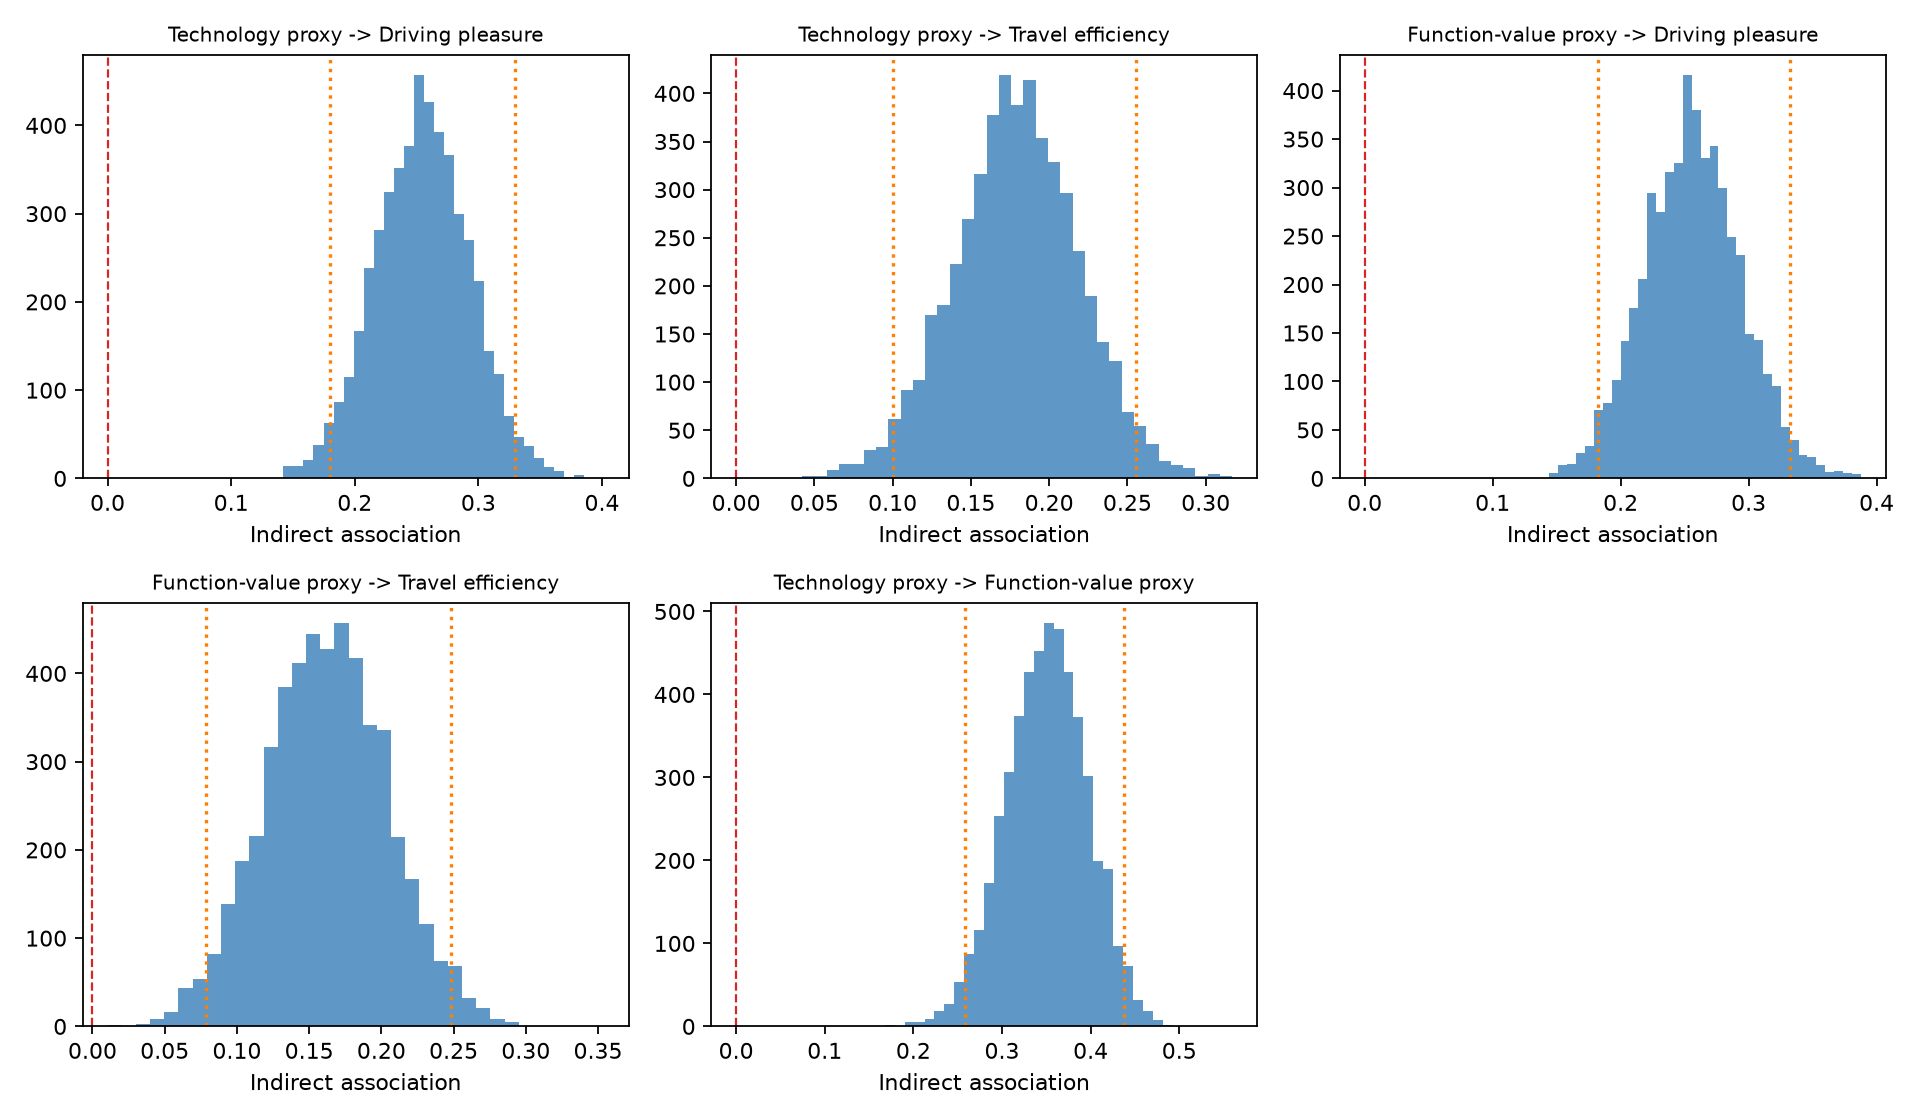

In [5]:
mediation = pd.read_csv(RUN_DIR / "mediation_paths.csv")
mediation_view = mediation[[
    "x", "mediator", "n_obs", "indirect", "ci_low", "ci_high",
    "bootstrap_iterations", "bootstrap_valid", "bootstrap_failures"
]].copy()
display(mediation_view.style.format({
    "indirect": "{:.3f}", "ci_low": "{:.3f}", "ci_high": "{:.3f}"
}))

# The saved plot is generated by the analysis module; this cell only displays it.
plot_path = RUN_DIR / "mediation_bootstrap_distributions.png"
if plot_path.exists():
    display(Image(filename=str(plot_path)))


## 6. 异质性结果

In [6]:
hetero = pd.read_csv(RUN_DIR / "heterogeneity_results.csv")
display(hetero[[
    "group_var", "n_obs", "n_groups", "df_diff", "lr_stat",
    "p_raw", "p_holm", "status"
]].style.format({"lr_stat": "{:.3f}", "p_raw": "{:.3g}", "p_holm": "{:.3g}"}))
print("Use p_holm for the five-comparison interpretation; group codes remain questionnaire codes.")


,group_var,n_obs,n_groups,df_diff,lr_stat,p_raw,p_holm,status
0,gender_gp,622,2,2,8.756,0.0126,0.0628,ok
1,age_gp,622,5,8,15.994,0.0425,0.17,ok
2,income_gp,622,4,6,3.735,0.713,0.713,ok
3,exp_gp,622,5,8,15.148,0.0563,0.17,ok
4,freq_gp,622,5,8,11.490,0.175,0.351,ok


Use p_holm for the five-comparison interpretation; group codes remain questionnaire codes.


## 7. 机器学习与 SHAP

,feature_set_name,model,accuracy_mean,macro_f1_mean,qwk_mean,ordinal_mae_mean
0,controls,majority,0.424,0.119,0.000,0.804
1,controls,ordered_logit,0.423,0.119,0.001,0.805
2,controls,random_forest,0.408,0.136,-0.006,0.830
3,core,majority,0.424,0.119,0.000,0.804
4,core,ordered_logit,0.508,0.404,0.650,0.571
5,core,random_forest,0.502,0.366,0.533,0.612
6,extended,majority,0.424,0.119,0.000,0.804
7,extended,ordered_logit,0.545,0.460,0.685,0.523
8,extended,random_forest,0.535,0.425,0.619,0.569


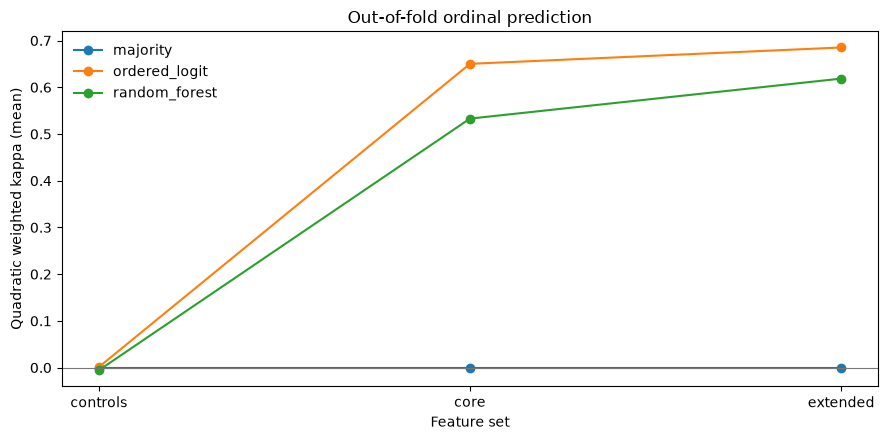

SHAP status: ok
SHAP target: P(Y>=4) when supported; raw-output fallback is flagged


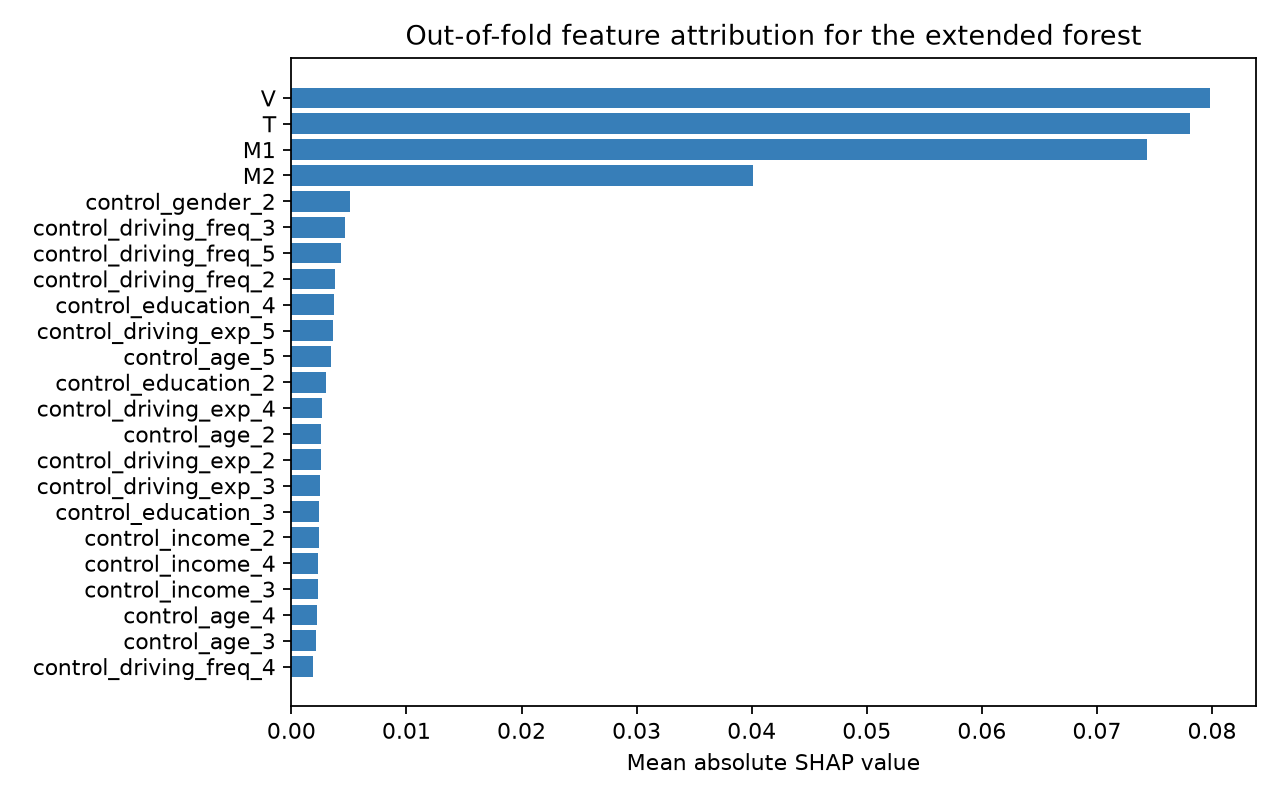

In [7]:
ml_summary = pd.read_csv(RUN_DIR / "ml_summary.csv")
summary_view = ml_summary[[
    "feature_set_name", "model", "accuracy_mean", "macro_f1_mean",
    "qwk_mean", "ordinal_mae_mean"
]].copy()
display(summary_view.style.format({
    "accuracy_mean": "{:.3f}", "macro_f1_mean": "{:.3f}",
    "qwk_mean": "{:.3f}", "ordinal_mae_mean": "{:.3f}"
}))

# Compact, reproducible comparison figure from the saved fold summary.
plot_df = ml_summary[ml_summary["model"].isin(["majority", "ordered_logit", "random_forest"])].copy()
fig, ax = plt.subplots(figsize=(9, 4.5))
for model_name, group in plot_df.groupby("model"):
    ax.plot(group["feature_set_name"], group["qwk_mean"], marker="o", label=model_name)
ax.axhline(0, color="#777", linewidth=0.8)
ax.set_ylabel("Quadratic weighted kappa (mean)")
ax.set_xlabel("Feature set")
ax.set_title("Out-of-fold ordinal prediction")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

ml_meta = json.loads((RUN_DIR / "ml_run_metadata.json").read_text(encoding="utf-8"))
print("SHAP status:", ml_meta.get("shap", {}).get("status"))
print("SHAP target:", ml_meta.get("shap", {}).get("target"))
shap_path = RUN_DIR / "shap_importance.png"
if shap_path.exists():
    display(Image(filename=str(shap_path)))


## 8. 输出完整性检查

In [8]:
expected_files = [
    "run_metadata.json", "audit.json", "ordered_logit_coefficients.csv",
    "ordered_logit_diagnostics.json", "mediation_paths.csv",
    "heterogeneity_results.csv", "ml_summary.csv", "ml_oof_predictions.csv",
    "ml_run_metadata.json", "shap_importance.csv", "shap_importance.png",
]
checks = pd.DataFrame({
    "artifact": expected_files,
    "exists": [(RUN_DIR / name).exists() for name in expected_files],
})
display(checks)

# Verify that the selected run refers to the same local data file.
def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

recorded_sha = metadata.get("data_sha256")
current_sha = sha256(DATA_PATH)
print("Data SHA recorded:", recorded_sha)
print("Data SHA current:  ", current_sha)
print("Data hash matches:  ", recorded_sha == current_sha)
failed_folds = pd.read_csv(RUN_DIR / "ml_fold_metrics.csv")
print("Failed ML folds:", int((failed_folds["status"] != "ok").sum()))


,artifact,exists
0,run_metadata.json,True
1,audit.json,True
2,ordered_logit_coefficients.csv,True
3,ordered_logit_diagnostics.json,True
4,mediation_paths.csv,True
5,heterogeneity_results.csv,True
6,ml_summary.csv,True
7,ml_oof_predictions.csv,True
8,ml_run_metadata.json,True
9,shap_importance.csv,True


Data SHA recorded: 8d15c4765ba63be6140f6f3d61508a26e59e1199df048f6889bce4311067075a
Data SHA current:   8d15c4765ba63be6140f6f3d61508a26e59e1199df048f6889bce4311067075a
Data hash matches:   True
Failed ML folds: 0


## 9. 解释边界

- OR 解释为控制其他变量后的条件关联，不写成因果影响。
- Bootstrap 区间不跨 0 只能说明当前样本中的探索性间接关联，不标注完全/部分中介。
- Holm 校正后的异质性 p 值用于多重比较判断；未校正的偶然显著不能作为稳定群体差异。
- QWK、准确率和 SHAP 反映折外预测表现，不是经济模型的因果验证。
- 如果更换 `RUN_ID`，必须重新检查数据 SHA、Git 状态和所有结果文件是否来自同一个运行目录。
